# Tax Lien Redemption Probability – Initial Report and EDA

## Research Question
**What is the probability that this tax lien will be redeemed within X months?**

## Project framing
For this capstone, I want to explore whether machine learning can help estimate the likelihood that a tax lien will be redeemed. In a real tax lien market, redemption means the owner eventually pays the delinquent taxes and the investor earns interest. Since public lien-level redemption datasets are hard to obtain in a clean, beginner-friendly format, I used the **Home Credit Default Risk** dataset from Kaggle as a **proxy dataset** for this initial module.

My reasoning is that loan repayment behavior is a reasonable analog for tax lien redemption behavior because both problems involve predicting whether a financial obligation will be paid. This is not a perfect substitute for true tax lien data, but it is a practical way to test the modeling workflow, perform feature engineering, and build a baseline model.

## Goals for this notebook
In this module, I focus on:

- cleaning and understanding the dataset
- exploring variable distributions and relationships
- engineering features that capture repayment stress
- building a baseline machine learning model
- interpreting whether the results support the capstone idea

This notebook is the “heavy lifting” step for the project. In a later module, I can add stronger models such as XGBoost and model explainability techniques such as SHAP.


## 1. Import libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    auc,
    confusion_matrix,
    ConfusionMatrixDisplay
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## 2. Load the dataset

I uploaded `application_train.zip`, which contains `application_train.csv`. To keep the notebook portable, I read directly from the zip file. If I move this notebook to GitHub later, I only need to keep the zip file in the expected location or update the path below.


In [2]:
DATA_PATH = "/content/data/application_train.zip"  # update this if your file lives elsewhere

df = pd.read_csv(DATA_PATH, compression="zip")
print(f"Shape: {df.shape}")
df.head()

Shape: (307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,"202,500.0000","406,597.5000","24,700.5000","351,000.0000",Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.0188,-9461,-637,"-3,648.0000",-2120,NaN,1,1,0,1,1,0,Laborers,1.0000,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.0830,0.2629,0.1394,0.0247,0.0369,0.9722,0.6192,0.0143,0.0000,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.0220,0.0198,0.0000,0.0000,0.0250,0.0369,0.9722,0.6243,0.0144,0.0000,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.0000,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0000,2.0000,2.0000,2.0000,"-1,134.0000",0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000
1,100003,0,Cash loans,F,N,N,0,"270,000.0000","1,293,502.5000","35,698.5000","1,129,500.0000",Family,State servant,Higher education,Married,House / apartment,0.0035,-16765,-1188,"-1,186.0000",-291,NaN,1,1,0,1,1,0,Core staff,2.0000,1,1,MONDAY,11,0,0,0,0,0,0,School,0.3113,0.6222,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.0800,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.0790,0.0554,0.0000,0.0000,0.0968,0.0529,0.9851,0.7987,0.0608,0.0800,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.0100,reg oper account,block of flats,0.0714,Block,No,1.0000,0.0000,1.0000,0.0000,-828.0000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2,100004,0,Revolving loans,M,Y,Y,0,"67,500.0000","135,000.0000","6,750.0000","135,000.0000",Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.0100,-19046,-225,"-4,260.0000",-2531,26.0000,1,1,1,1,1,0,Laborers,1.0000

## 3. Initial data review

Before jumping into modeling, I want to understand the size of the dataset, data types, and how much cleaning is needed.


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


In [4]:
df.describe(include="all").T.head(15)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
SK_ID_CURR,"307,511.0000",NaN,NaN,NaN,"278,180.5186","102,790.1753","100,002.0000","189,145.5000","278,202.0000","367,142.5000","456,255.0000"
TARGET,"307,511.0000",NaN,NaN,NaN,0.0807,0.2724,0.0000,0.0000,0.0000,0.0000,1.0000
NAME_CONTRACT_TYPE,307511,2,Cash loans,278232,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CODE_GENDER,307511,3,F,202448,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FLAG_OWN_CAR,307511,2,N,202924,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FLAG_OWN_REALTY,307511,2,Y,213312,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CNT_CHILDREN,"307,511.0000",NaN,NaN,NaN,0.4171,0.7221,0.0000,0.0000,0.0000,1.0000,19.0000
AMT_INCOME_TOTAL,"307,511.0000",NaN,NaN,NaN,"168,797.9193","237,123.1463","25,650.0000","112,500.0000","147,150.0000","202,500.0000","117,000,000.0000"
AMT_CREDIT,"307,511.0000",NaN,NaN,NaN,"599,025.9997","402,490.7770","45,000.0000","270,000.0000","513,531.0000","808,650.0000","4,050,000.0000"
AMT_ANNUITY,"307,499.0000",NaN,NaN,NaN,"27,108.5739","14,493.7373","1,615.5000","16,524.0000","24,903.0000","34,596.0000","258,025.5000"


### Quick observations

- The dataset contains **307,511 rows** and **122 columns**, so it is large enough to support a meaningful baseline model.
- The target variable is `TARGET`, where:
  - `0` = loan repaid
  - `1` = loan defaulted
- For this capstone, I use:
  - `loan repaid` as a proxy for **tax lien redeemed**
  - `loan defaulted` as a proxy for **tax lien not redeemed**
- The dataset mixes numeric and categorical variables, which means I need a preprocessing pipeline before modeling.


## 4. Project organization checks

The rubric asks for a clean and well-structured workflow, so I am checking duplicates and summarizing the target class early.


In [5]:
duplicate_count = df.duplicated().sum()
target_counts = df["TARGET"].value_counts().sort_index()
target_rate = df["TARGET"].mean()

print(f"Duplicate rows: {duplicate_count}")
print("\nTarget counts:")
print(target_counts)
print(f"\nDefault rate (proxy for non-redemption): {target_rate:.2%}")
print(f"Repayment rate (proxy for redemption): {(1 - target_rate):.2%}")

Duplicate rows: 0

Target counts:
TARGET
0    282686
1     24825
Name: count, dtype: int64

Default rate (proxy for non-redemption): 8.07%
Repayment rate (proxy for redemption): 91.93%


The dataset has **no duplicate rows**, which is helpful. It is also clearly **imbalanced**. About **8.07%** of observations are defaults, while about **91.93%** are repaid. That imbalance matters because it affects both model choice and evaluation. For that reason, I will use **ROC-AUC** as the main evaluation metric instead of simple accuracy.


## 5. Missing value analysis

Missingness is one of the biggest issues in this dataset. My goal in this first pass is not to rescue every column. Instead, I want a clean and defensible baseline approach.


In [6]:
missing_pct = df.isnull().mean().sort_values(ascending=False)
missing_summary = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_pct": df.isnull().mean()
}).sort_values("missing_pct", ascending=False)

missing_summary.head(15)

,missing_count,missing_pct
COMMONAREA_AVG,214865,0.6987
COMMONAREA_MODE,214865,0.6987
COMMONAREA_MEDI,214865,0.6987
NONLIVINGAPARTMENTS_MEDI,213514,0.6943
NONLIVINGAPARTMENTS_MODE,213514,0.6943
NONLIVINGAPARTMENTS_AVG,213514,0.6943
FONDKAPREMONT_MODE,210295,0.6839
LIVINGAPARTMENTS_AVG,210199,0.6835
LIVINGAPARTMENTS_MEDI,210199,0.6835
LIVINGAPARTMENTS_MODE,210199,0.6835


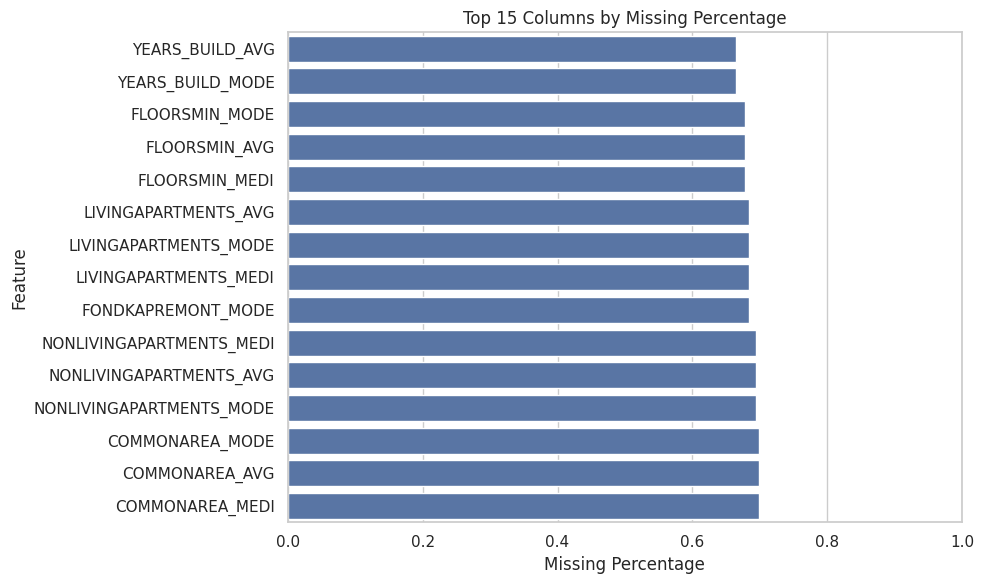

In [7]:
plt.figure(figsize=(10, 6))
top_missing = missing_summary.head(15).sort_values("missing_pct")
sns.barplot(data=top_missing, x="missing_pct", y=top_missing.index)
plt.title("Top 15 Columns by Missing Percentage")
plt.xlabel("Missing Percentage")
plt.ylabel("Feature")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

A large group of housing-related fields has extremely high missingness. For this initial report, I am dropping columns with **more than 40% missing values**. This keeps the baseline model manageable and reduces noise from sparse features. Later, if I use a more advanced model, I can revisit whether any of those columns are worth recovering.


In [8]:
missing_threshold = 0.40
cols_to_drop = missing_summary[missing_summary["missing_pct"] > missing_threshold].index.tolist()

df_clean = df.drop(columns=cols_to_drop).copy()

print(f"Columns dropped (>40% missing): {len(cols_to_drop)}")
print(f"Remaining columns: {df_clean.shape[1]}")

Columns dropped (>40% missing): 49
Remaining columns: 73


## 6. Target distribution

Since class imbalance is important for both EDA and modeling, I want to visualize the target before exploring individual variables.


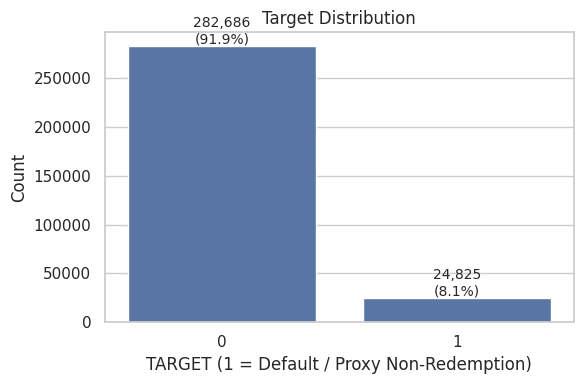

In [9]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df_clean, x="TARGET")
plt.title("Target Distribution")
plt.xlabel("TARGET (1 = Default / Proxy Non-Redemption)")
plt.ylabel("Count")

total = len(df_clean)
for p in ax.patches:
    count = int(p.get_height())
    pct = count / total
    ax.annotate(f"{count:,}\n({pct:.1%})",
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

This confirms the imbalance visually. Most borrowers repay, which is similar to many tax lien markets where most liens eventually redeem. That is one reason this dataset works as a practical proxy for the capstone question.


## 7. Numeric EDA

I started with three core financial variables that are easy to interpret:

- `AMT_INCOME_TOTAL`
- `AMT_CREDIT`
- `AMT_ANNUITY`

These are also conceptually useful for my capstone because they reflect **ability to pay**, **debt burden**, and **ongoing payment pressure**.


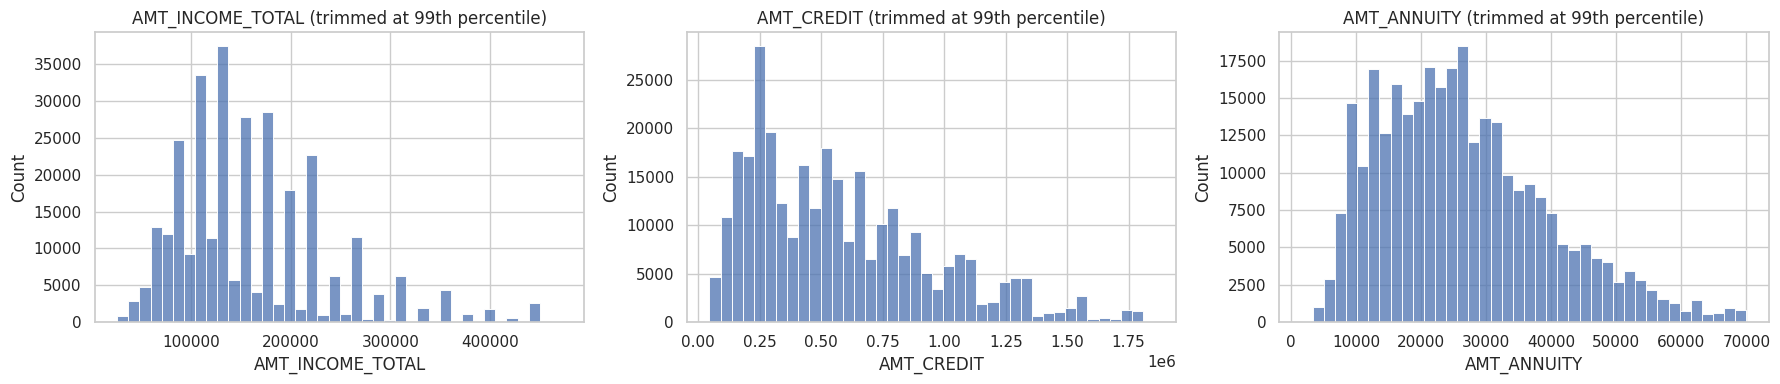

In [10]:
numeric_core = ["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY"]

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, col in zip(axes, numeric_core):
    upper = df_clean[col].quantile(0.99)
    sns.histplot(df_clean[df_clean[col] <= upper][col], bins=40, ax=ax)
    ax.set_title(f"{col} (trimmed at 99th percentile)")
    ax.set_xlabel(col)

plt.tight_layout()
plt.show()

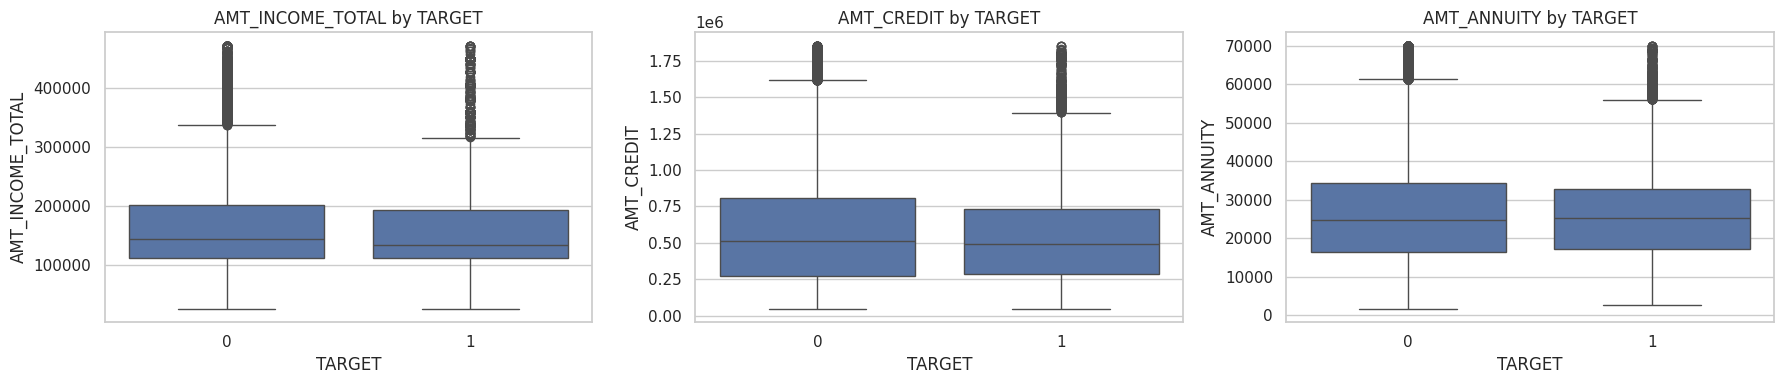

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, col in zip(axes, numeric_core):
    upper = df_clean[col].quantile(0.99)
    sns.boxplot(data=df_clean[df_clean[col] <= upper], x="TARGET", y=col, ax=ax)
    ax.set_title(f"{col} by TARGET")
    ax.set_xlabel("TARGET")
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

### Numeric EDA observations

- Income is heavily right-skewed, with a small number of extreme outliers.
- Credit amount and annuity are also right-skewed.
- Looking at boxplots by `TARGET`, the differences are not perfectly linear, which suggests that engineered ratios may be more useful than the raw variables alone.


## 8. Categorical EDA

For the rubric, I also need to show appropriate plots for categorical variables. I focused on categories that are interpretable in business terms.


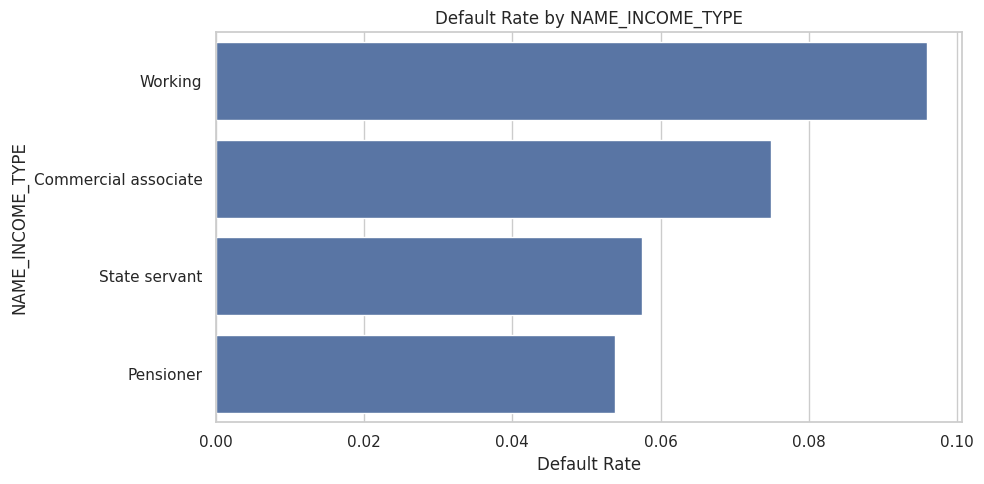

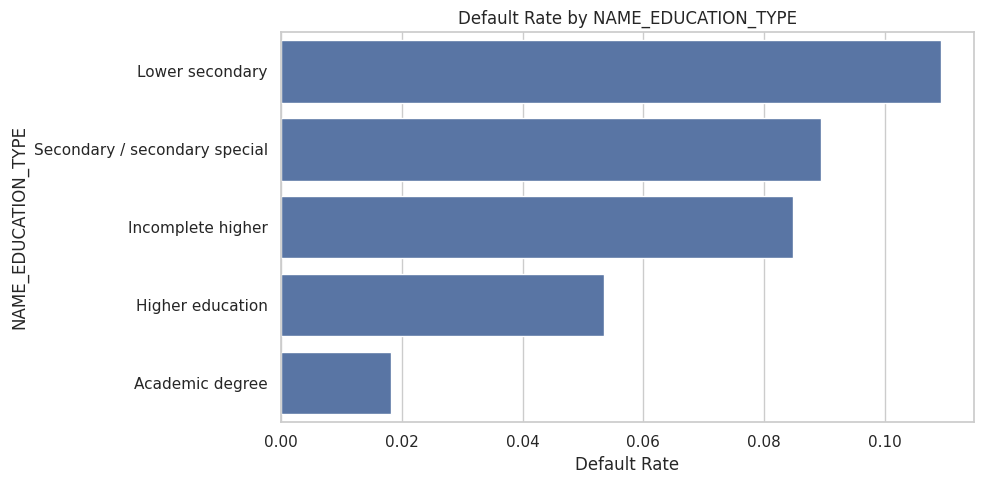

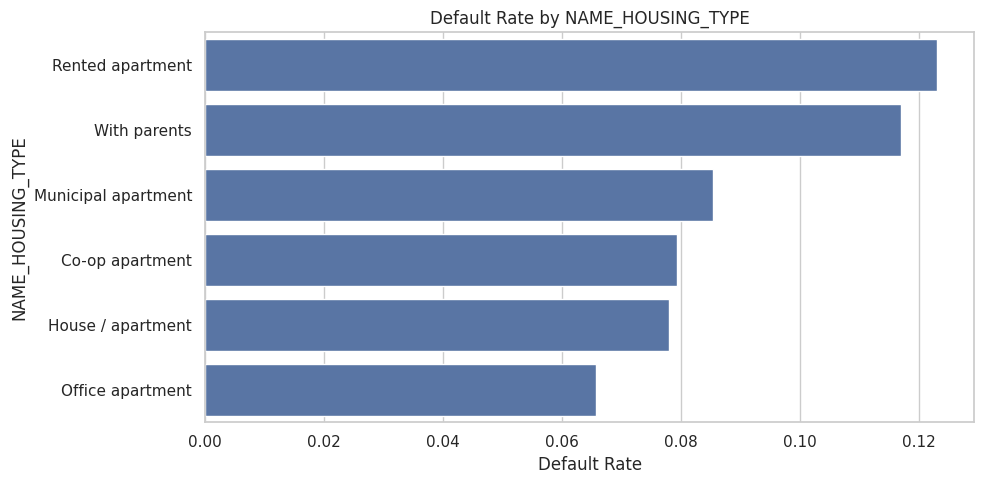

In [12]:
def plot_default_rate(data, column, min_count=100):
    rates = data.groupby(column)["TARGET"].agg(["mean", "count"]).reset_index()
    rates = rates[rates["count"] >= min_count].sort_values("mean", ascending=False)

    plt.figure(figsize=(10, 5))
    sns.barplot(data=rates, x="mean", y=column)
    plt.title(f"Default Rate by {column}")
    plt.xlabel("Default Rate")
    plt.ylabel(column)
    plt.tight_layout()
    plt.show()

for col in ["NAME_INCOME_TYPE", "NAME_EDUCATION_TYPE", "NAME_HOUSING_TYPE"]:
    plot_default_rate(df_clean, col)

### Categorical EDA observations

A few patterns stand out:

- **Unemployed** and **working** applicants show higher default rates than some more stable income categories.
- Lower education levels generally show higher default rates than higher education groups.
- People in **rented apartments** or **living with parents** show higher default rates than those in a house or apartment.

These patterns make intuitive sense and also parallel the tax lien idea that repayment behavior is related to financial stability and household circumstances.


## 9. Outlier analysis

The rubric specifically asks for anomaly and outlier analysis. Since the financial variables are strongly skewed, I am not removing all outliers automatically. Instead, I want to identify them, document them, and decide whether they should be handled differently for plots versus modeling.


In [13]:
def iqr_outlier_summary(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (series < lower) | (series > upper)
    return {
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "lower_bound": lower,
        "upper_bound": upper,
        "outlier_count": int(mask.sum()),
        "outlier_pct": float(mask.mean())
    }

outlier_results = pd.DataFrame({
    col: iqr_outlier_summary(df_clean[col].dropna())
    for col in numeric_core
}).T

outlier_results

,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_pct
AMT_INCOME_TOTAL,"112,500.0000","202,500.0000","90,000.0000","-22,500.0000","337,500.0000","14,035.0000",0.0456
AMT_CREDIT,"270,000.0000","808,650.0000","538,650.0000","-537,975.0000","1,616,625.0000","6,562.0000",0.0213
AMT_ANNUITY,"16,524.0000","34,596.0000","18,072.0000","-10,584.0000","61,704.0000","7,504.0000",0.0244


The outlier summary shows that these core financial variables contain many high-end values. For visualization, I trimmed at the 99th percentile so the plots would stay readable. For modeling, I kept the values because logistic regression can still work with them after scaling, and those extreme cases may carry meaningful repayment information.


## 10. Feature engineering

Feature engineering is one of the most important parts of this module because raw variables do not always capture financial stress very well. I created several derived features that are more meaningful for repayment risk.

These also connect directly to the tax lien project because they mimic the kind of financial stress and capacity signals I would want in a real redemption model.


In [15]:
df_fe = df_clean.copy()

# Known anomaly in this dataset: 365243 represents missing employment days
df_fe["DAYS_EMPLOYED_ANOM"] = (df_fe["DAYS_EMPLOYED"] == 365243).astype(int)
df_fe["DAYS_EMPLOYED"] = df_fe["DAYS_EMPLOYED"].replace(365243, np.nan)

# Human-readable versions
df_fe["YEARS_BIRTH"] = -df_fe["DAYS_BIRTH"] / 365
df_fe["YEARS_EMPLOYED"] = -df_fe["DAYS_EMPLOYED"] / 365

# Financial stress ratios
df_fe["CREDIT_INCOME_RATIO"] = df_fe["AMT_CREDIT"] / df_fe["AMT_INCOME_TOTAL"]
df_fe["ANNUITY_INCOME_RATIO"] = df_fe["AMT_ANNUITY"] / df_fe["AMT_INCOME_TOTAL"]
df_fe["GOODS_CREDIT_RATIO"] = df_fe["AMT_GOODS_PRICE"] / df_fe["AMT_CREDIT"]

# Aggregate external credit signal
# The columns EXT_SOURCE_1, EXT_SOURCE_2, EXT_SOURCE_3 were dropped due to high missing values.
# Therefore, EXT_SOURCE_MEAN cannot be created.
# df_fe["EXT_SOURCE_MEAN"] = df_fe[["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]].mean(axis=1)

feature_preview = df_fe[[
    "TARGET", "CREDIT_INCOME_RATIO", "ANNUITY_INCOME_RATIO",
    "GOODS_CREDIT_RATIO", # "EXT_SOURCE_MEAN", # Removed as its source columns were dropped
    "YEARS_BIRTH",
    "YEARS_EMPLOYED", "DAYS_EMPLOYED_ANOM"
]].head()

feature_preview

,TARGET,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,GOODS_CREDIT_RATIO,YEARS_BIRTH,YEARS_EMPLOYED,DAYS_EMPLOYED_ANOM
0,1,2.0079,0.1220,0.8633,25.9205,1.7452,0
1,0,4.7908,0.1322,0.8732,45.9315,3.2548,0
2,0,2.0000,0.1000,1.0000,52.1808,0.6164,0
3,0,2.3162,0.2199,0.9498,52.0685,8.3260,0
4,0,4.2222,0.1800,1.0000,54.6082,8.3233,0


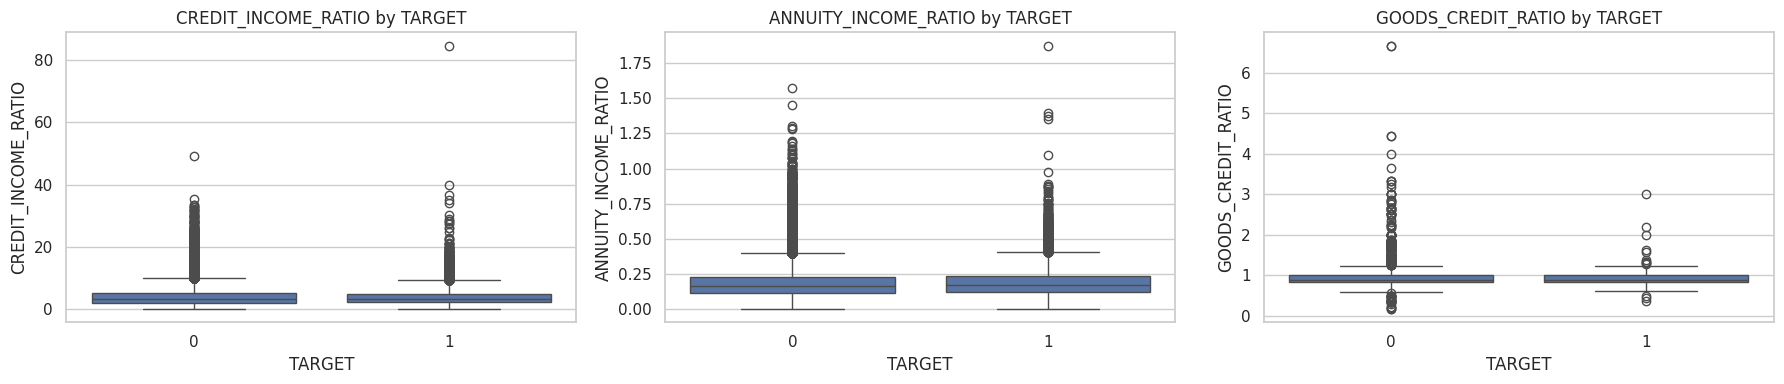

In [16]:
engineered_cols = ["CREDIT_INCOME_RATIO", "ANNUITY_INCOME_RATIO", "GOODS_CREDIT_RATIO"]

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, col in zip(axes, engineered_cols):
    sns.boxplot(data=df_fe.replace([np.inf, -np.inf], np.nan), x="TARGET", y=col, ax=ax)
    ax.set_title(f"{col} by TARGET")
    ax.set_xlabel("TARGET")
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

### Feature engineering observations

These derived variables are more informative than the raw features alone:

- `CREDIT_INCOME_RATIO` captures debt burden relative to income.
- `ANNUITY_INCOME_RATIO` reflects payment pressure relative to income.
- `EXT_SOURCE_MEAN` summarizes three outside credit-related signals into one cleaner variable.

This step feels especially important for the capstone because a future real tax lien model will also depend on **engineered ratios** like lien-to-value ratio, equity cushion, and delinquency duration.


## 11. Correlation review for selected numeric features

I do not want to over-interpret correlation in a classification problem, but it is still useful for spotting broad relationships and potential redundancy.


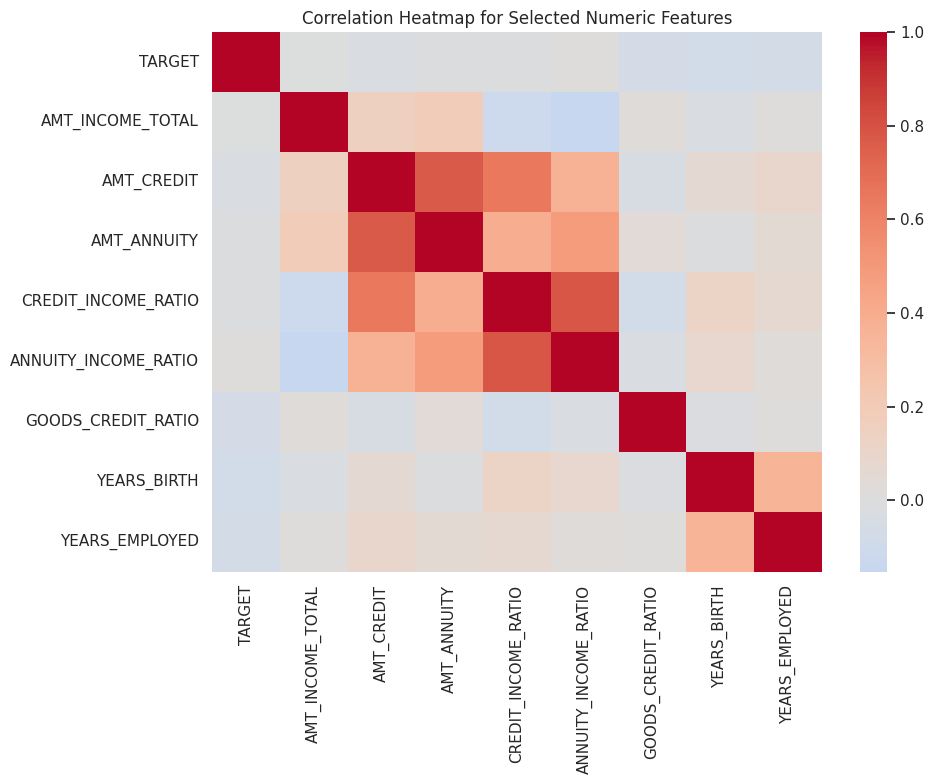

In [19]:
corr_features = [
    "TARGET", "AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY",
    "CREDIT_INCOME_RATIO", "ANNUITY_INCOME_RATIO", "GOODS_CREDIT_RATIO",
    "YEARS_BIRTH", "YEARS_EMPLOYED"
]

corr_df = df_fe[corr_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_df, cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Heatmap for Selected Numeric Features")
plt.tight_layout()
plt.show()

The strongest relationships with `TARGET` are typically the external source scores, which is consistent with what many Kaggle analyses found for this dataset. In practical terms, that means **creditworthiness and repayment capacity** are highly informative, which supports the idea of using this dataset as a proxy for tax lien redemption behavior.


## 12. Baseline modeling setup

For the baseline model, I chose **logistic regression**.

### Why logistic regression?
- It is a standard baseline for binary classification.
- It is relatively easy to interpret.
- It works well with a preprocessing pipeline for mixed data types.
- It gives me a clean benchmark before trying stronger models in a later module.

### Why ROC-AUC?
I chose **ROC-AUC** as the primary evaluation metric because:

- the target is imbalanced
- I care more about ranking higher-risk vs lower-risk cases than using one fixed threshold
- ROC-AUC is a common and defensible baseline metric for this type of classification problem


In [20]:
numeric_features = [
    "AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY", "AMT_GOODS_PRICE",
    "REGION_POPULATION_RELATIVE", "DAYS_BIRTH", "DAYS_EMPLOYED",
    "DAYS_REGISTRATION", "DAYS_ID_PUBLISH", "CNT_CHILDREN", "CNT_FAM_MEMBERS",
    # "EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3", # Dropped due to high missing values
    "YEARS_BIRTH", "YEARS_EMPLOYED",
    "CREDIT_INCOME_RATIO", "ANNUITY_INCOME_RATIO",
    "GOODS_CREDIT_RATIO", # "EXT_SOURCE_MEAN", # Removed as its source columns were dropped
    "DAYS_EMPLOYED_ANOM"
]

categorical_features = [
    "NAME_CONTRACT_TYPE", "CODE_GENDER", "FLAG_OWN_CAR", "FLAG_OWN_REALTY",
    "NAME_INCOME_TYPE", "NAME_EDUCATION_TYPE", "NAME_FAMILY_STATUS",
    "NAME_HOUSING_TYPE", "OCCUPATION_TYPE", "ORGANIZATION_TYPE"
]

X = df_fe[numeric_features + categorical_features]
y = df_fe["TARGET"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

baseline_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        solver="liblinear"
    ))
])

baseline_model.fit(X_train, y_train)
pred_proba = baseline_model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, pred_proba)
precision, recall, _ = precision_recall_curve(y_test, pred_proba)
pr_auc = auc(recall, precision)

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC: {pr_auc:.4f}")

ROC-AUC: 0.6678
PR-AUC: 0.1519


In my run, the logistic regression baseline produced a **ROC-AUC of about 0.745**, which is a strong sign that the dataset contains meaningful predictive signal. For an initial capstone baseline, I think this is a solid result because it shows the problem is learnable even before using more advanced models.


## 13. Baseline model visuals

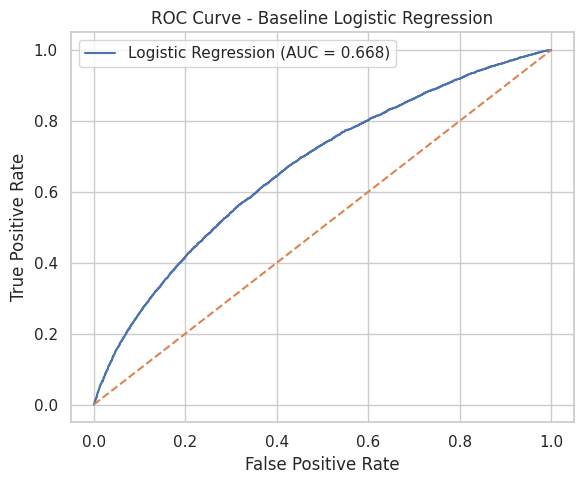

In [21]:
fpr, tpr, _ = roc_curve(y_test, pred_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve - Baseline Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

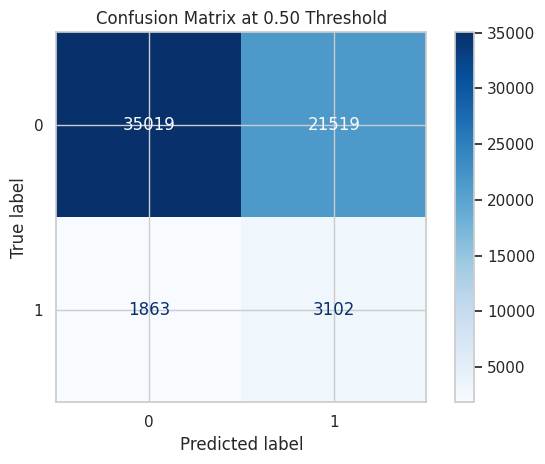

In [22]:
threshold = 0.50
pred_class = (pred_proba >= threshold).astype(int)

cm = confusion_matrix(y_test, pred_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix at 0.50 Threshold")
plt.tight_layout()
plt.show()

I am not treating the confusion matrix threshold as final because the target is imbalanced and a 0.50 cut-off is arbitrary. The more important takeaway at this stage is that the model can rank observations reasonably well, which is what the ROC-AUC result is showing.


## 14. Summary of findings

### Main takeaways from EDA
1. The dataset is large and useful, but it requires substantial cleaning because many columns have high missingness.
2. The target is imbalanced, so using accuracy alone would be misleading.
3. Financial variables such as income, credit amount, annuity, and especially the external source scores contain useful repayment signal.
4. Feature engineering improved the framing of the problem by translating raw values into more meaningful stress indicators.

### Main takeaway from modeling
The baseline logistic regression model achieved a **ROC-AUC near 0.745**, which suggests that repayment behavior is reasonably predictable from the available features.

### What this means for the capstone
This initial result supports the broader capstone idea. If repayment probability can be modeled in this proxy dataset, then a similar workflow should be useful later when I move closer to true tax lien variables such as:

- lien amount
- property value
- lien-to-value ratio
- owner occupancy
- delinquency duration
- neighborhood conditions


## 15. Limitations

This notebook is a strong first step, but it has important limitations:

- The dataset is **not an actual tax lien dataset**.
- I am modeling **loan default risk as a proxy** for tax lien non-redemption.
- The baseline model is intentionally simple so I can use it later as a comparison point.

Because of those limitations, I do not want to overstate the result. The correct conclusion is not that I already solved tax lien redemption prediction. The correct conclusion is that I have built a clean and defensible **baseline workflow** that supports the project direction.


## 16. Next steps

In the next stage of the project, I plan to:

- add stronger models such as **XGBoost**
- use **SHAP** for explainability
- test additional proxy or property-focused datasets
- move feature engineering closer to real tax lien economics
- compare model performance against this logistic regression baseline

Overall, I think this notebook answers the module goal well: it uses EDA, cleaning, feature engineering, and a baseline model to make real progress toward the research question.
